## Selección de modelo con algoritmos básicos

### Proyecto:
Pacientes con problemas de hígado - India

**Autor:** Mariana Bedoya Arismendy

### Fecha:
2026-08-19

### Incidencia:
12 - Selección del mejor modelo

### Descripción:

Este notebook selecciona el modelo de Machine Learning comparando ocho
algoritmos básicos de clasificación (regresión logística, LDA, SGD, SVM lineal,
k-vecinos por radio, Naive Bayes gaussiano, árbol de decisión y random forest)
sobre el dataset de pacientes con problemas de hígado (ILPD).

El flujo sigue tres pasos: (1) evaluación rápida de los ocho algoritmos con sus
hiperparámetros por defecto para descartar los peores, (2) validación cruzada de
los finalistas con comparación estadística y (3) ajuste de hiperparámetros de los
dos mejores. Los modelos, como mínimo, tienen que superar al modelo base
(heurística clínica) construido en el notebook
`01-heuristic_model-mba-2026-08-19.ipynb`.

## 📚 Importar librerías

Importamos `pandas` y `numpy` para manipular los datos, los componentes de
scikit-learn para preprocesar (`ColumnTransformer`, imputadores, codificadores,
escalado), evaluar modelos (métricas de clasificación, validación cruzada,
curva de aprendizaje) y construir pipelines, y `matplotlib` para las gráficas.

In [1]:
# librerías base para ciencia de datos
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn as sk
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    KFold,
    ShuffleSplit,
    cross_val_score,
    learning_curve,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## 💾 Cargar datos

Cargamos el mismo archivo Parquet de la etapa intermedia que usaron el EDA, el
Feature Engineering y el baseline: las 11 variables clínicas con los tipos de
datos ya corregidos. La ruta se construye de forma relativa a la raíz del
proyecto para que el notebook funcione en cualquier instalación.

In [2]:
DATA_DIR = Path.cwd().resolve().parents[1] / "data"
DATA_PATH = DATA_DIR / "02_intermediate/Pacientes_porblemas_higado_india_type_fixed.parquet"

assert DATA_PATH.exists(), f"No se encuentra el archivo del proyecto: {DATA_PATH}"

pacientes_df = pd.read_parquet(DATA_PATH, engine="pyarrow")

print(f"Dataset cargado: {pacientes_df.shape[0]} filas y {pacientes_df.shape[1]} columnas")
pacientes_df.head()

Dataset cargado: 663 filas y 11 columnas


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187.0,16.0,18.0,6.8,3.3,0.9,1
1,62,Male,10.9,5.5,699.0,64.0,100.0,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490.0,60.0,68.0,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182.0,14.0,20.0,6.8,3.4,1.0,1
4,72,Male,3.9,2.0,195.0,27.0,59.0,7.3,2.4,0.4,1


In [3]:
# versiones de las librerías para reproducibilidad
print("Versión de Python:", sys.version)
print("Versión de pandas:", pd.__version__)
print("Versión de scikit-learn:", sk.__version__)

Versión de Python: 3.12.11 (main, Jul  1 2025, 05:29:09) [GCC 12.2.0]
Versión de pandas: 3.0.5
Versión de scikit-learn: 1.9.0


## 👷 Preparación de los datos

La variable objetivo es `Dataset`, con etiquetas `'1'` (problemas de hígado,
clase positiva) y `'2'` (sin problemas); la recodificamos como 1/0 para los
clasificadores de scikit-learn, igual que en el baseline. Las variables
predictoras son las 10 restantes: edad, género y las ocho pruebas hepáticas.

Aplicamos exactamente la misma limpieza de las etapas anteriores (duplicados
exactos → filas sin etiqueta → bilirrubinas inconsistentes, siempre antes del
split) para que todos los notebooks de modelado trabajen sobre los mismos 585
registros:

In [4]:
# 1. Duplicados exactos: antes del split para evitar registros idénticos
#    en entrenamiento y prueba.
filas_iniciales = len(pacientes_df)
limpio_df = pacientes_df.drop_duplicates()
print(f"Tras eliminar duplicados: {len(limpio_df)} filas (-{filas_iniciales - len(limpio_df)})")

# 2. Registros sin etiqueta en el objetivo: la variable objetivo no se imputa.
filas_sin_etiqueta = int(limpio_df["Dataset"].isna().sum())
limpio_df = limpio_df[limpio_df["Dataset"].notna()]
print(f"Tras descartar filas sin etiqueta: {len(limpio_df)} filas (-{filas_sin_etiqueta})")

# 3. Bilirrubinas inconsistentes (directa mayor que la total): errores de captura.
inconsistente = (limpio_df["Direct_Bilirubin"] > limpio_df["Total_Bilirubin"]).fillna(False)
limpio_df = limpio_df[~inconsistente]
print(f"Tras descartar filas inconsistentes: {len(limpio_df)} filas (-{int(inconsistente.sum())})")

# objetivo binario: 1 = problemas de hígado ('1'), 0 = sin problemas ('2')
pacientes_features = limpio_df.copy()
pacientes_features["Dataset"] = (pacientes_features["Dataset"] == "1").astype(int)

pacientes_features.info()

Tras eliminar duplicados: 603 filas (-60)
Tras descartar filas sin etiqueta: 588 filas (-15)
Tras descartar filas inconsistentes: 585 filas (-3)
<class 'pandas.DataFrame'>
Index: 585 entries, 0 to 662
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   Age                         584 non-null    Int64   
 1   Gender                      581 non-null    category
 2   Total_Bilirubin             582 non-null    Float64 
 3   Direct_Bilirubin            581 non-null    Float64 
 4   Alkaline_Phosphotase        576 non-null    Float64 
 5   Alamine_Aminotransferase    573 non-null    Float64 
 6   Aspartate_Aminotransferase  577 non-null    Float64 
 7   Total_Protiens              578 non-null    Float64 
 8   Albumin                     583 non-null    Float64 
 9   Albumin_and_Globulin_Ratio  581 non-null    Float64 
 10  Dataset                     585 non-null    int64   
dtypes: Floa

La limpieza deja el dataset en 585 filas (663 → 603 → 588 → 585), con 414
pacientes con problemas de hígado (70,8%) y 171 sin problemas (29,2%).

Quedan valores faltantes en varias pruebas hepáticas y en el género: no se
eliminan filas por ellos, se imputan dentro del pipeline de preprocesamiento
para que la imputación se calcule solo con los datos de entrenamiento y evitar
fugas de información.

In [5]:
pacientes_features.isna().sum()

Age                            1
Gender                         4
Total_Bilirubin                3
Direct_Bilirubin               4
Alkaline_Phosphotase           9
Alamine_Aminotransferase      12
Aspartate_Aminotransferase     8
Total_Protiens                 7
Albumin                        2
Albumin_and_Globulin_Ratio     4
Dataset                        0
dtype: int64

In [6]:
pacientes_features.sample(10, random_state=42)

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
404,22,Male,0.8,0.2,198.0,20.0,26.0,6.8,3.9,1.3,1
443,42,Female,0.7,0.2,152.0,35.0,81.0,6.2,3.2,1.06,1
100,27,Male,0.6,0.2,161.0,27.0,28.0,3.7,1.6,0.76,0
493,65,Male,0.7,0.2,265.0,30.0,28.0,5.2,1.8,0.52,0
551,29,Male,1.2,0.4,160.0,20.0,22.0,6.2,3.0,0.9,0
325,42,Male,0.8,0.2,158.0,27.0,23.0,6.7,3.1,0.8,0
122,58,Male,1.7,0.8,188.0,60.0,84.0,5.9,3.5,1.4,0
282,50,Male,0.7,0.2,188.0,12.0,14.0,7.0,3.4,0.9,1
146,66,Female,2.9,1.3,168.0,21.0,38.0,5.5,1.8,0.4,1
381,39,Male,0.6,0.2,188.0,28.0,43.0,8.1,3.3,0.6,1


## 👨‍🏭 Ingeniería de características (preprocesamiento)

El preprocesamiento es simple y común a los ocho algoritmos:

- **Numéricas** (edad y las ocho pruebas hepáticas): imputación por la mediana y
  **estandarización**. El escalado no cambia nada para los árboles (es una
  transformación monótona por columna), pero es necesario para comparar en
  igualdad de condiciones a los modelos lineales (regresión logística, LDA, SGD,
  SVM) y de distancias (k-vecinos por radio), cuyas escalas originales van de
  décimas (ratio albúmina/globulina) a miles de U/L (transaminasas).
- **Categóricas** (`Gender`): imputación por la moda y codificación one-hot.

In [7]:
# columnas numéricas: edad y las ocho pruebas hepáticas
cols_numeric = [
    "Age",
    "Total_Bilirubin",
    "Direct_Bilirubin",
    "Alkaline_Phosphotase",
    "Alamine_Aminotransferase",
    "Aspartate_Aminotransferase",
    "Total_Protiens",
    "Albumin",
    "Albumin_and_Globulin_Ratio",
]

# columnas categóricas nominales
cols_categoric = ["Gender"]

In [8]:
numeric_pipe = Pipeline(
    steps=[
        ("imputador_mediana", SimpleImputer(strategy="median")),
        ("escalado", StandardScaler()),
    ]
)

categorical_pipe = Pipeline(
    steps=[
        ("imputador_moda", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="infrequent_if_exist", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numericas", numeric_pipe, cols_numeric),
        ("categoricas", categorical_pipe, cols_categoric),
    ],
    verbose_feature_names_out=True,
)

# salida como DataFrame de pandas para conservar los nombres de las columnas
preprocessor.set_output(transform="pandas")
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericas', ...), ('categoricas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``

## ✂️ División entrenamiento / prueba

División 80 %/20 % **estratificada por el objetivo** con `random_state=42`, la
misma partición de los notebooks del baseline y del AutoML: 468 pacientes para
entrenamiento y 117 para prueba, conservando el desbalance 71/29 en ambos
conjuntos.

In [9]:
SEED = 42

X_features = pacientes_features.drop("Dataset", axis="columns")
Y_target = pacientes_features["Dataset"]

# 80 % entrenamiento, 20 % prueba
x_train, x_test, y_train, y_test = train_test_split(
    X_features, Y_target, test_size=0.2, stratify=Y_target, random_state=SEED
)

print(f"Entrenamiento: {x_train.shape[0]} filas ({int(y_train.sum())} con problemas de hígado)")
print(f"Prueba: {x_test.shape[0]} filas ({int(y_test.sum())} con problemas de hígado)")

Entrenamiento: 468 filas (331 con problemas de hígado)
Prueba: 117 filas (83 con problemas de hígado)


In [10]:
x_train.shape, y_train.shape

((468, 10), (468,))

In [11]:
x_test.shape, y_test.shape

((117, 10), (117,))

### Ejemplo del pipeline de preprocesamiento

Ajustamos el preprocesador con el entrenamiento y transformamos la prueba para
verificar que produce 11 columnas (9 numéricas escaladas + 2 del one-hot del
género) y que no queda ningún faltante:

In [12]:
# entrenar el preprocesamiento solo con los datos de entrenamiento
preprocessor.fit(x_train)

# obtener el nombre de las columnas de salida del preprocesamiento
# usando .get_feature_names_out()
feature_names = preprocessor.get_feature_names_out()

# transformar x_test con el preprocesamiento ya ajustado
x_test_transformed = preprocessor.transform(x_test)
x_test_transformed = pd.DataFrame(x_test_transformed, columns=feature_names, index=x_test.index)
x_test_transformed.info()

<class 'pandas.DataFrame'>
Index: 117 entries, 524 to 169
Data columns (total 11 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   numericas__Age                         117 non-null    float64
 1   numericas__Total_Bilirubin             117 non-null    float64
 2   numericas__Direct_Bilirubin            117 non-null    float64
 3   numericas__Alkaline_Phosphotase        117 non-null    float64
 4   numericas__Alamine_Aminotransferase    117 non-null    float64
 5   numericas__Aspartate_Aminotransferase  117 non-null    float64
 6   numericas__Total_Protiens              117 non-null    float64
 7   numericas__Albumin                     117 non-null    float64
 8   numericas__Albumin_and_Globulin_Ratio  117 non-null    float64
 9   categoricas__Gender_Female             117 non-null    float64
 10  categoricas__Gender_Male               117 non-null    float64
dtypes: float64(11)
memor

In [13]:
x_test_transformed.sample(5, random_state=42)

,numericas__Age,numericas__Total_Bilirubin,numericas__Direct_Bilirubin,numericas__Alkaline_Phosphotase,numericas__Alamine_Aminotransferase,numericas__Aspartate_Aminotransferase,numericas__Total_Protiens,numericas__Albumin,numericas__Albumin_and_Globulin_Ratio,categoricas__Gender_Female,categoricas__Gender_Male
236,-1.426249,-0.392595,-0.445065,-0.006796,-0.139783,-0.254959,1.361228,0.874972,-0.118760,0.0,1.0
203,-1.487888,-0.360821,-0.408536,-0.610808,-0.292892,-0.314690,-0.067146,0.490477,0.842829,0.0,1.0
414,1.224211,-0.297272,-0.298948,-0.159711,-0.287789,-0.305259,-1.209844,-1.175667,-0.759820,0.0,1.0
190,0.916018,0.481196,0.650817,0.046724,0.171539,-0.022322,0.123304,0.746807,1.067200,0.0,1.0
242,-0.994779,-0.392595,-0.445065,-0.369968,-0.277581,-0.308403,1.646902,1.259467,0.201769,1.0,0.0


## 🤖 Modelos

La buena práctica es importar las librerías al inicio del notebook; en este
notebook se importan en la celda donde se usan, siguiendo el material del
curso.

En esta primera exploración se usan modelos básicos de Machine Learning con
sus hiperparámetros por defecto:

- Regresión logística
- Análisis discriminante lineal (LDA)
- Clasificador de descenso de gradiente estocástico (SGD)
- Máquina de vectores de soporte lineal (SVC)
- Clasificador de k-vecinos por radio (Radius Neighbors)
- Naive Bayes gaussiano
- Árbol de decisión
- Random Forest

El Radius Neighbors usa radio 3.0: como las variables están estandarizadas,
las distancias euclidianas típicas entre pacientes están entre 1 y 6, y un
radio de 3.0 define un vecindario razonable; radios mayores degeneran en la
clase mayoritaria y menores dejan pacientes sin vecinos.

In [14]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import RadiusNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

## Selección básica de modelos

Los modelos se entrenan con los hiperparámetros por defecto y los que tengan
el mejor desempeño serán seleccionados para ajustarse en el siguiente paso.

### Funciones auxiliares

In [15]:
def summarize_classification(y_test, y_pred, y_score):
    """Calcula las métricas de clasificación para un conjunto de predicciones.

    `y_score` recibe las probabilidades (o scores continuos) de la clase
    positiva: la AUC pierde su significado si se calcula con etiquetas duras.
    """
    acc = accuracy_score(y_test, y_pred, normalize=True)
    prec = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_score)

    return {"accuracy": acc, "precision": prec, "recall": recall, "f1": f1, "roc": roc}

In [16]:
def build_model(
    classifier_fn,
    preprocessor: ColumnTransformer,
    data_params: dict,
    test_frac: float = 0.2,
) -> dict:
    """
    Función para entrenar un modelo de clasificación

    Args:
        classifier_fn: función de clasificación
        preprocessor (ColumnTransformer): pipeline de preprocesamiento
        data_params (dict): diccionario con 'name_of_y_col',
                            'names_of_x_cols' y 'dataset'
        test_frac (float): fracción de datos para la prueba, 0.2 por defecto

    Returns:
        dict: diccionario con las métricas del modelo en train y test

    """

    # extraer los parámetros de los datos
    name_of_y_col = data_params["name_of_y_col"]
    names_of_x_cols = data_params["names_of_x_cols"]
    dataset = data_params["dataset"]

    # separar las columnas de características y la columna objetivo
    X = dataset[names_of_x_cols]
    Y = dataset[name_of_y_col]

    # dividir los datos en entrenamiento y prueba, estratificando por el
    # objetivo para conservar el desbalance 71/29 en ambos conjuntos
    x_train, x_test, y_train, y_test = train_test_split(
        X, Y, test_size=test_frac, stratify=Y, random_state=1234
    )

    # crear el pipeline con el preprocesamiento y el modelo de clasificación
    classifier_pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", classifier_fn)])

    # entrenar el pipeline del clasificador
    model = classifier_pipe.fit(x_train, y_train)

    # predecir los datos de prueba
    y_pred = model.predict(x_test)

    # predecir los datos de entrenamiento
    y_pred_train = model.predict(x_train)

    # scores continuos para la AUC: probabilidades si el modelo las ofrece,
    # y la función de decisión en caso contrario (p. ej. LinearSVC)
    if hasattr(model, "predict_proba"):
        y_score_train = model.predict_proba(x_train)[:, 1]
        y_score_test = model.predict_proba(x_test)[:, 1]
    else:
        y_score_train = model.decision_function(x_train)
        y_score_test = model.decision_function(x_test)

    # calcular las métricas de desempeño
    train_summary = summarize_classification(y_train, y_pred_train, y_score_train)
    test_summary = summarize_classification(y_test, y_pred, y_score_test)

    return {"train": train_summary, "test": test_summary}

In [17]:
FEATURES = list(x_train.columns)
FEATURES

['Age',
 'Gender',
 'Total_Bilirubin',
 'Direct_Bilirubin',
 'Alkaline_Phosphotase',
 'Alamine_Aminotransferase',
 'Aspartate_Aminotransferase',
 'Total_Protiens',
 'Albumin',
 'Albumin_and_Globulin_Ratio']

### Entrenamiento y evaluación simple

La idea es un entrenamiento y evaluación simples para ver cuáles son los peores
modelos y descartarlos.

In [18]:
result_dict = {}
models = {
    "logistic": LogisticRegression(solver="liblinear"),
    "lda": LinearDiscriminantAnalysis(),
    "sgd": SGDClassifier(),
    "svc": LinearSVC(C=1.0, max_iter=1000, tol=1e-3, dual=False),
    "radius_neighbors": RadiusNeighborsClassifier(radius=3.0),
    "naive_bayes": GaussianNB(),
    "decision_tree": DecisionTreeClassifier(),
    "random_forest": RandomForestClassifier(),
}

data_params = {
    "name_of_y_col": "Dataset",
    "names_of_x_cols": FEATURES,
    "dataset": pacientes_features,
}
for model_name, model in models.items():
    result_dict[model_name] = build_model(model, preprocessor, data_params)
    print(f"{model_name}: {result_dict[model_name]['test']}")

logistic: {'accuracy': 0.6923076923076923, 'precision': 0.7373737373737373, 'recall': 0.8795180722891566, 'f1': 0.8021978021978022, 'roc': 0.5574060949681077}
lda: {'accuracy': 0.6666666666666666, 'precision': 0.7115384615384616, 'recall': 0.891566265060241, 'f1': 0.7914438502673797, 'roc': 0.5046066619418852}
sgd: {'accuracy': 0.6153846153846154, 'precision': 0.796875, 'recall': 0.6144578313253012, 'f1': 0.6938775510204082, 'roc': 0.6160524450744154}


svc: {'accuracy': 0.6752136752136753, 'precision': 0.7319587628865979, 'recall': 0.8554216867469879, 'f1': 0.7888888888888889, 'roc': 0.5453579021970234}
radius_neighbors: {'accuracy': 0.7008547008547008, 'precision': 0.7068965517241379, 'recall': 0.9879518072289156, 'f1': 0.8241206030150754, 'roc': 0.4939759036144578}
naive_bayes: {'accuracy': 0.5213675213675214, 'precision': 0.9354838709677419, 'recall': 0.3493975903614458, 'f1': 0.5087719298245614, 'roc': 0.6452870304748405}


decision_tree: {'accuracy': 0.6324786324786325, 'precision': 0.7564102564102564, 'recall': 0.7108433734939759, 'f1': 0.7329192546583851, 'roc': 0.5760099220411056}
random_forest: {'accuracy': 0.7008547008547008, 'precision': 0.7608695652173914, 'recall': 0.8433734939759037, 'f1': 0.8, 'roc': 0.5981573352232459}


### Comparación de modelos

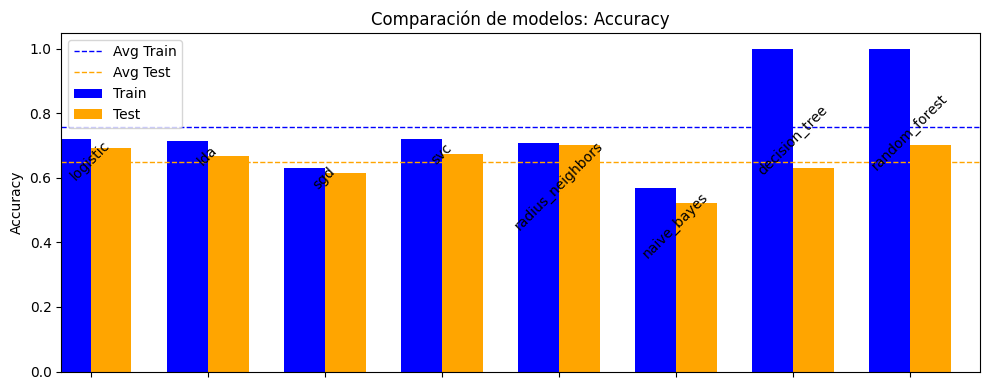

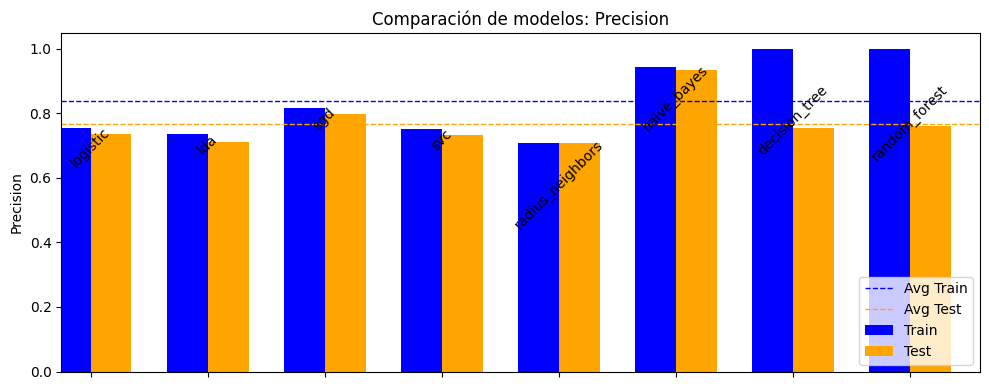

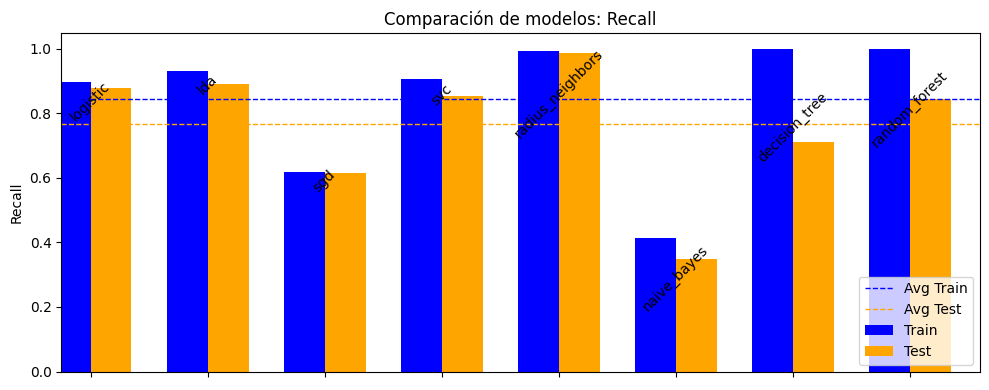

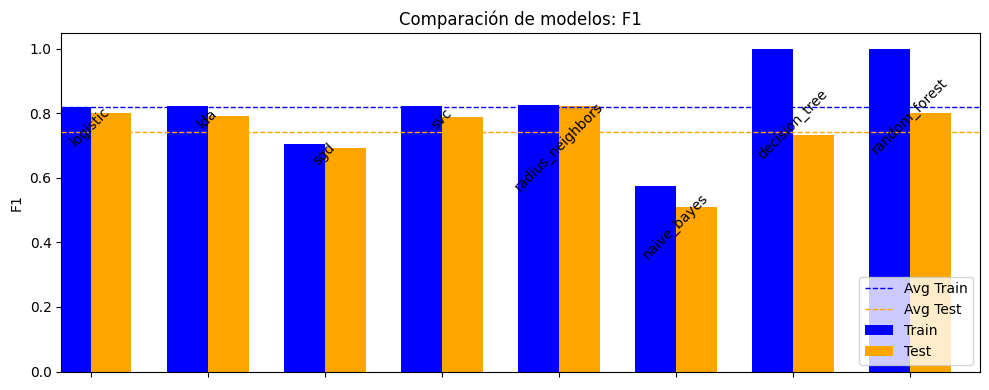

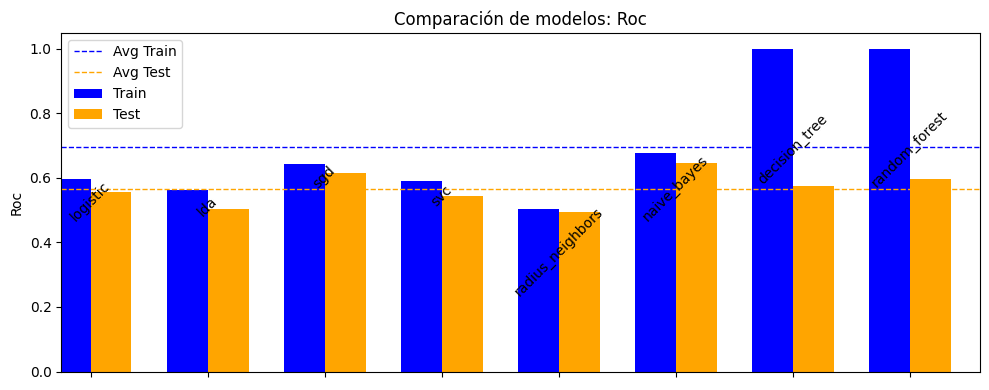

In [19]:
# convertir el result_dict a un DataFrame para facilitar el gráfico
metrics = ["accuracy", "precision", "recall", "f1", "roc"]
models = list(result_dict.keys())
data_train = {
    metric: {model: result_dict[model]["train"][metric] for model in models} for metric in metrics
}
data_test = {
    metric: {model: result_dict[model]["test"][metric] for model in models} for metric in metrics
}

df_train = pd.DataFrame(data_train)
df_test = pd.DataFrame(data_test)

# gráfico de barras para cada métrica
for metric in metrics:
    fig, ax = plt.subplots(figsize=(10, 4))
    width = 0.35  # el ancho de las barras

    df_train[metric].plot(kind="bar", ax=ax, width=width, position=1, label="Train", color="blue")
    df_test[metric].plot(kind="bar", ax=ax, width=width, position=0, label="Test", color="orange")

    # líneas horizontales con el desempeño promedio
    avg_train = df_train[metric].mean()
    avg_test = df_test[metric].mean()
    ax.axhline(avg_train, color="blue", linestyle="--", linewidth=1, label="Avg Train")
    ax.axhline(avg_test, color="orange", linestyle="--", linewidth=1, label="Avg Test")

    # ajustar el diseño
    ax.set_ylabel(metric.capitalize())
    ax.set_title(f"Comparación de modelos: {metric.capitalize()}")
    ax.legend()

    # etiquetas del eje x dentro de las barras y rotadas 90 grados
    ax.set_xticks(range(len(df_train.index)))
    ax.set_xticklabels([])

    # dibujar las etiquetas del eje x dentro de las barras rotadas 90 grados
    for i, label in enumerate(df_train.index):
        bar_center = (df_train.loc[label, metric] + df_test.loc[label, metric]) / 2
        ax.text(i, bar_center, label, ha="center", va="center_baseline", rotation=45)

    plt.tight_layout()
    plt.show()

In [20]:
# crear un DataFrame combinando df_train y df_test
df_combined = pd.concat([df_train.add_suffix("_train"), df_test.add_suffix("_test")], axis=1)

# calcular la diferencia entre los valores de train y test
df_combined["accuracy_diff"] = df_combined["accuracy_train"] - df_combined["accuracy_test"]
df_combined["precision_diff"] = df_combined["precision_train"] - df_combined["precision_test"]
df_combined["recall_diff"] = df_combined["recall_train"] - df_combined["recall_test"]
df_combined["f1_diff"] = df_combined["f1_train"] - df_combined["f1_test"]
df_combined["roc_diff"] = df_combined["roc_train"] - df_combined["roc_test"]

# detectar modelos con sobreajuste (diferencia significativa entre train y test)
overfitting_threshold = 0.1  # umbral para considerar sobreajuste
overfitting_models = df_combined[
    (df_combined["accuracy_diff"] > overfitting_threshold)
    | (df_combined["precision_diff"] > overfitting_threshold)
    | (df_combined["recall_diff"] > overfitting_threshold)
    | (df_combined["f1_diff"] > overfitting_threshold)
    | (df_combined["roc_diff"] > overfitting_threshold)
]

# calcular el desempeño promedio en train y test para cada métrica
mean_performance_train = df_combined[
    ["accuracy_train", "precision_train", "recall_train", "f1_train", "roc_train"]
].mean()
mean_performance_test = df_combined[
    ["accuracy_test", "precision_test", "recall_test", "f1_test", "roc_test"]
].mean()

# detectar modelos con bajo desempeño
# (desempeño en train y test por debajo del promedio de los demás modelos)
low_performance_models = df_combined[
    (df_combined["accuracy_train"] < mean_performance_train["accuracy_train"])
    & (df_combined["accuracy_test"] < mean_performance_test["accuracy_test"])
    & (df_combined["precision_train"] < mean_performance_train["precision_train"])
    & (df_combined["precision_test"] < mean_performance_test["precision_test"])
    & (df_combined["recall_train"] < mean_performance_train["recall_train"])
    & (df_combined["recall_test"] < mean_performance_test["recall_test"])
    & (df_combined["f1_train"] < mean_performance_train["f1_train"])
    & (df_combined["f1_test"] < mean_performance_test["f1_test"])
    & (df_combined["roc_train"] < mean_performance_train["roc_train"])
    & (df_combined["roc_test"] < mean_performance_test["roc_test"])
]

print(f"Modelos con sobreajuste: {list(overfitting_models.index)} ")
print(f"Modelos con bajo desempeño: {list(low_performance_models.index)} ")

Modelos con sobreajuste: ['decision_tree', 'random_forest'] 
Modelos con bajo desempeño: [] 


In [21]:
# detectar modelos con desempeño similar en train y test
similar_performance_threshold = 0.05  # umbral para considerar desempeño similar
similar_performance_models = df_combined[
    (df_combined["accuracy_diff"].abs() < similar_performance_threshold)
    & (df_combined["precision_diff"].abs() < similar_performance_threshold)
    & (df_combined["recall_diff"].abs() < similar_performance_threshold)
    & (df_combined["f1_diff"].abs() < similar_performance_threshold)
    & (df_combined["roc_diff"].abs() < similar_performance_threshold)
]

print(f"Modelos con desempeño similar en train y test: {list(similar_performance_models.index)}")

Modelos con desempeño similar en train y test: ['logistic', 'sgd', 'radius_neighbors']


In [22]:
overfitting_models

,accuracy_train,precision_train,recall_train,f1_train,roc_train,accuracy_test,precision_test,recall_test,f1_test,roc_test,accuracy_diff,precision_diff,recall_diff,f1_diff,roc_diff
decision_tree,1.0,1.0,1.0,1.0,1.0,0.632479,0.75641,0.710843,0.732919,0.576010,0.367521,0.24359,0.289157,0.267081,0.423990
random_forest,1.0,1.0,1.0,1.0,1.0,0.700855,0.76087,0.843373,0.800000,0.598157,0.299145,0.23913,0.156627,0.200000,0.401843


In [23]:
low_performance_models

,accuracy_train,precision_train,recall_train,f1_train,roc_train,accuracy_test,precision_test,recall_test,f1_test,roc_test,accuracy_diff,precision_diff,recall_diff,f1_diff,roc_diff


In [24]:
similar_performance_models

,accuracy_train,precision_train,recall_train,f1_train,roc_train,accuracy_test,precision_test,recall_test,f1_test,roc_test,accuracy_diff,precision_diff,recall_diff,f1_diff,roc_diff
logistic,0.722222,0.755725,0.897281,0.820442,0.598276,0.692308,0.737374,0.879518,0.802198,0.557406,0.029915,0.018351,0.017763,0.018244,0.040869
sgd,0.632479,0.816733,0.619335,0.704467,0.641784,0.615385,0.796875,0.614458,0.693878,0.616052,0.017094,0.019858,0.004878,0.010590,0.025732
radius_neighbors,0.707265,0.709052,0.993958,0.827673,0.504278,0.700855,0.706897,0.987952,0.824121,0.493976,0.006410,0.002155,0.006006,0.003552,0.010302


Con base en los resultados:

**Modelos a descartar:**

- **Naive Bayes gaussiano**: el peor desempeño global (accuracy 0,52, recall 0,35);
  asume independencia entre las pruebas hepáticas, supuesto que el EDA descartó
  (bilirrubinas y transaminasas están correlacionadas).
- **Radius Neighbors**: su recall de 0,99 es engañoso: con ROC 0,49 (nivel de
  azar) predice prácticamente siempre la clase mayoritaria; el vecindario por
  radio no separa las clases en este dataset.
- **SGD**: el más inestable (accuracy 0,62) y sin ventaja frente a la regresión
  logística, que es su equivalente regularizado y estable.

Los modelos que pasan a la validación cruzada son:

- **Regresión logística** (simple, buen desempeño y alta interpretabilidad)
- **LDA** (simple, buen desempeño y alta interpretabilidad)
- **Árbol de decisión** (simple e interpretable, aunque tiende al sobreajuste)
- **Random Forest** (buen desempeño, aunque con hiperparámetros por defecto
  también sobreajusta: 1,0 en entrenamiento frente a 0,70 en prueba)

SVC lineal y Naive Bayes no se seleccionan: SVC tiene desempeño similar a la
regresión logística pero mayor costo de entrenamiento con más datos, y Naive
Bayes no ofrece margen de mejora con sus hiperparámetros.

## Selección de modelos con validación cruzada

In [25]:
# definir los modelos a evaluar
models = {
    "logistic": LogisticRegression(solver="liblinear"),
    "lda": LinearDiscriminantAnalysis(),
    "decision_tree": DecisionTreeClassifier(),
    "random_forest": RandomForestClassifier(),
}

# métricas de evaluación
scoring_metrics = ["accuracy", "f1", "precision", "recall"]

# KFold para la validación cruzada
kfold = KFold(n_splits=10, shuffle=True, random_state=1234)

# variable para almacenar los resultados de la validación cruzada
cv_results = {metric: {} for metric in scoring_metrics}

# evaluación con validación cruzada para cada modelo y métrica
for model_name, model in models.items():
    model_pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    for metric in scoring_metrics:
        cv_results[metric][model_name] = cross_val_score(
            model_pipe, x_train, y_train, cv=kfold, scoring=metric, n_jobs=8
        )

# convertir los resultados a un DataFrame de pandas por cada métrica
cv_results_df = {metric: pd.DataFrame(cv_results[metric]) for metric in scoring_metrics}

In [26]:
# crear un DataFrame con la media y desviación estándar por métrica y modelo
mean_std_data = []

for metric_name in scoring_metrics:
    for model_name in models:
        mean_score = cv_results_df[metric_name][model_name].mean()
        std_score = cv_results_df[metric_name][model_name].std()
        mean_std_data.append(
            {
                "Model": model_name,
                "Metric": metric_name,
                "Mean": mean_score,
                "Std": std_score,
            }
        )

mean_std_df = pd.DataFrame(mean_std_data)
mean_std_df

,Model,Metric,Mean,Std
0,logistic,accuracy,0.698520,0.053890
1,lda,accuracy,0.685384,0.076376
2,decision_tree,accuracy,0.653469,0.091354
3,random_forest,accuracy,0.702544,0.074580
4,logistic,f1,0.806622,0.040492
5,lda,f1,0.806231,0.056260
6,decision_tree,f1,0.753056,0.070986
7,random_forest,f1,0.806134,0.054065
8,logistic,precision,0.734254,0.052266
9,lda,precision,0.708462,0.063889


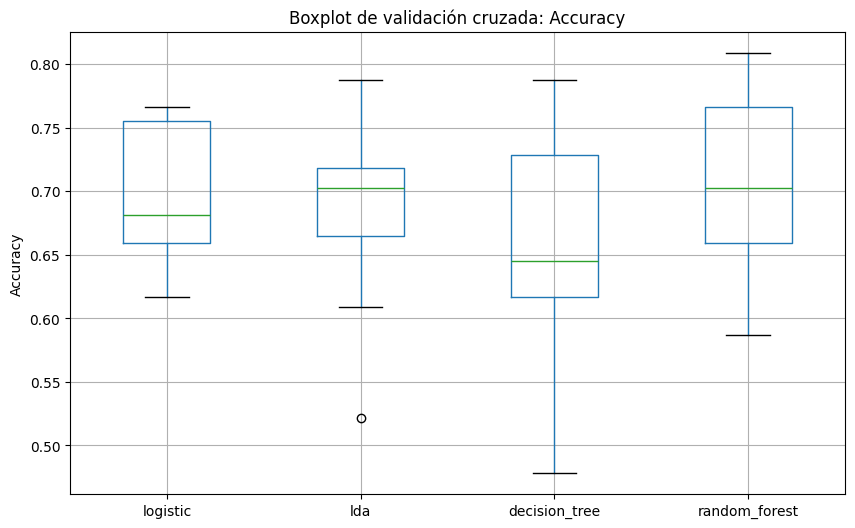

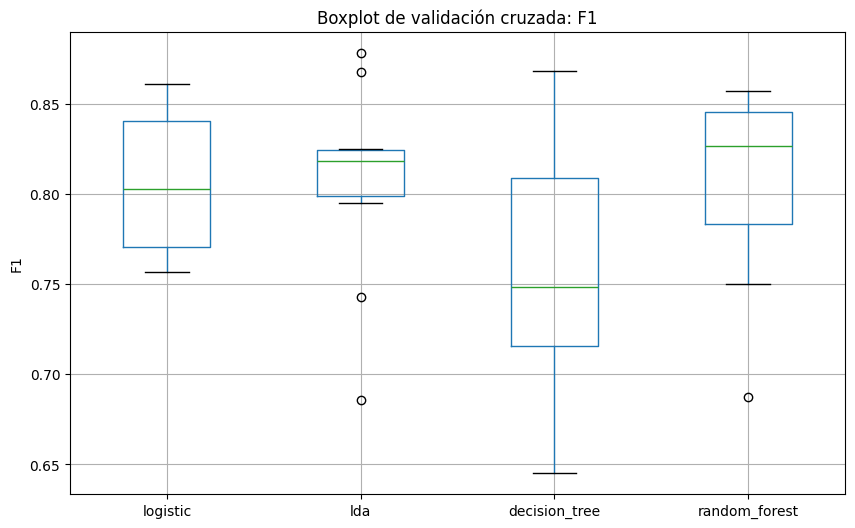

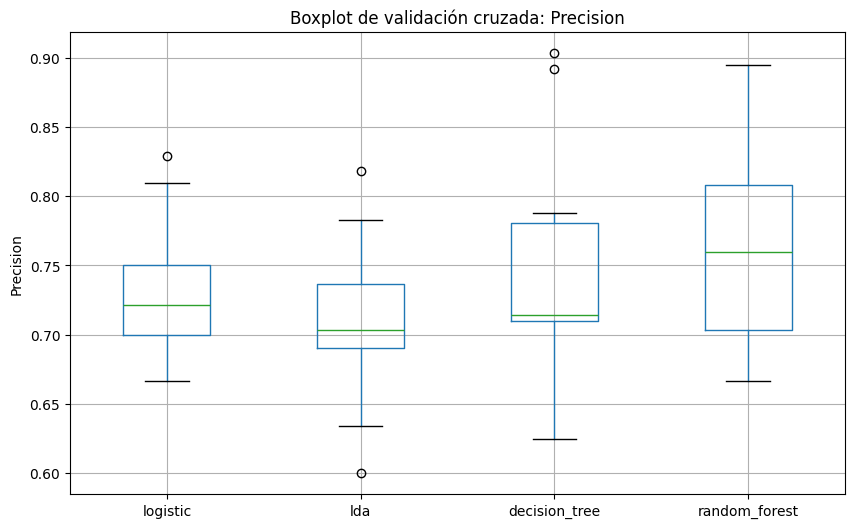

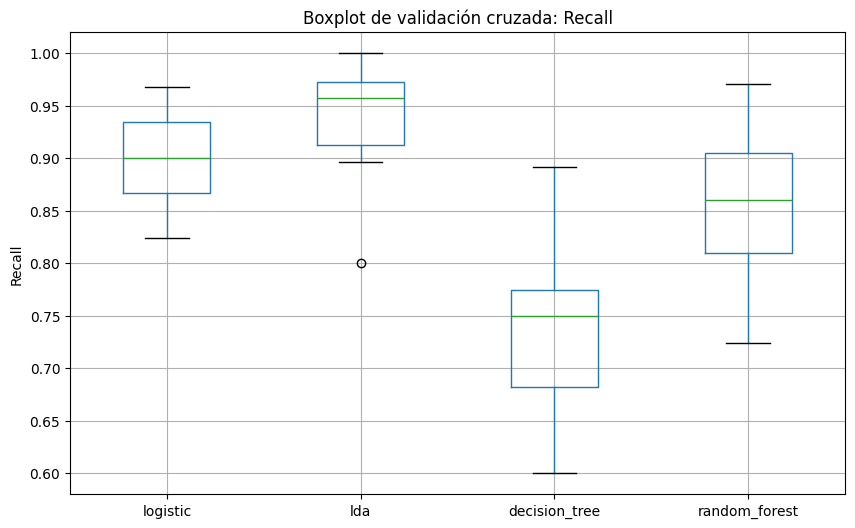

In [27]:
# boxplot de los resultados de la validación cruzada por métrica
for metric_name in scoring_metrics:
    plt.figure(figsize=(10, 6))
    cv_results_df[metric_name].boxplot()
    plt.title(f"Boxplot de validación cruzada: {metric_name.capitalize()}")
    plt.ylabel(f"{metric_name.capitalize()}")
    plt.show()

### Una sola métrica: recall

Se elige el **recall** (sensibilidad o tasa de verdaderos positivos) porque es
más importante identificar todos los casos positivos — pacientes con problemas
de hígado — para poder derivarlos a estudio.

El objetivo del modelo es identificar a todos los pacientes con problemas de
hígado sin dejar ninguno por fuera: un **falso negativo** significa un paciente
enfermo al que se le dice que está sano y que no se estudia más, que es el
error clínicamente más costoso. Los falsos positivos, en cambio, solo
generan pruebas de confirmación adicionales. Hay que tener presente, además,
que la clase positiva es mayoritaria en este dataset (70,8%), lo que infla
fácilmente el recall de un modelo que prediga casi siempre la clase 1: por eso
el recall se lee siempre junto al resto de métricas.

### Comparación estadística de modelos

In [28]:
result_df = cv_results_df["recall"]
result_df

,logistic,lda,decision_tree,random_forest
0,0.823529,0.911765,0.735294,0.970588
1,0.894737,0.947368,0.763158,0.842105
2,0.939394,0.969697,0.666667,0.909091
3,0.857143,0.914286,0.828571,0.800000
4,0.967742,1.000000,0.774194,0.838710
5,0.939394,1.000000,0.727273,0.878788
6,0.903226,0.967742,0.774194,0.935484
7,0.918919,0.972973,0.891892,0.891892
8,0.833333,0.800000,0.600000,0.733333
9,0.896552,0.896552,0.655172,0.724138


In [29]:
from scipy.stats import f_oneway

model1 = result_df["logistic"]
model2 = result_df["lda"]
model3 = result_df["decision_tree"]
model4 = result_df["random_forest"]

statistic, p_value = f_oneway(model1, model2, model3, model4)

print(f"Statistic: {statistic}")
print(f"p_value: {p_value}")

alpha = 0.05  # nivel de significancia

if p_value < alpha:
    print(
        "Hay una diferencia estadísticamente significativa "
        "en los resultados de la validación cruzada de los modelos."
    )
else:
    print(
        "No hay una diferencia estadísticamente significativa "
        "en los resultados de la validación cruzada de los modelos."
    )

Statistic: 14.41614433924991
p_value: 2.5021017210061397e-06
Hay una diferencia estadísticamente significativa en los resultados de la validación cruzada de los modelos.


A diferencia de lo que ocurre con otros datasets, aquí **sí hay una diferencia
estadísticamente significativa** entre los modelos (p-valor = 2,5e-06): el árbol
de decisión es claramente el peor en recall (0,742 ± 0,086), mientras que LDA
(0,938 ± 0,060), regresión logística (0,897 ± 0,047) y random forest
(0,852 ± 0,082) están más cerca, con LDA como el de mayor recall medio.

Dos modelos pasan al ajuste de hiperparámetros:

- **Regresión logística**: simple, interpretable, y con la regularización L1
  permite además hacer selección de variables.
- **Random Forest**: su implementación es distinta a la de la regresión
  logística y ofrece muchos hiperparámetros para afinar; además, el árbol solo
  quedó descartado por su recall, no por su capacidad de separación.

LDA se descarta como finalista porque su recall alto va acompañado de una
precisión de 0,71 — igual a la proporción de la clase positiva —, señal de que
tiende a predecir la clase mayoritaria, y no tiene hiperparámetros que
permitan corregir ese sesgo.

## Ajuste de hiperparámetros

Seleccionar los mejores hiperparámetros para los modelos elegidos en el paso
anterior.

### Regresión logística

In [30]:
from sklearn.model_selection import GridSearchCV

score = "recall"

# l1_ratio controla el tipo de regularización en sklearn >= 1.8:
# 0.0 = l2, 1.0 = l1, valores intermedios = elasticnet
# (el parámetro 'penalty' está deprecado; saga es el solver que soporta
# elasticnet)
parameters = {
    "model__l1_ratio": [0.0, 0.5, 1.0],
    "model__C": [0.1, 0.4, 0.8, 1, 2, 5],
}

modelo = LogisticRegression(solver="saga", max_iter=5000)
logistic_pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", modelo)])

grid_search = GridSearchCV(logistic_pipe, parameters, cv=5, scoring=score, return_train_score=True)
grid_search.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...ver='saga'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.1, 0.4, ...], 'model__l1_ratio': [0.0, 0.5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this spe

In [31]:
grid_search.best_params_

{'model__C': 0.1, 'model__l1_ratio': 1.0}

#### Evaluación regresión logística

In [32]:
# reconstruir el modelo con los mejores hiperparámetros encontrados
mejores_parametros = {
    clave.split("__")[1]: valor for clave, valor in grid_search.best_params_.items()
}
model = LogisticRegression(solver="saga", max_iter=5000, **mejores_parametros)
logistic_pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])

logistic_model = logistic_pipe.fit(x_train, y_train)

In [33]:
y_pred = logistic_model.predict(x_test)
y_score = logistic_model.predict_proba(x_test)[:, 1]

summarize_classification(y_test, y_pred, y_score)

{'accuracy': 0.7094017094017094,
 'precision': 0.7094017094017094,
 'recall': 1.0,
 'f1': 0.83,
 'roc': 0.7604535790219702}

### Random Forest

In [34]:
from sklearn.model_selection import GridSearchCV

score = "recall"

parameters = {
    "model__max_depth": [4, 5, 7, 9, 10],
    "model__max_features": [2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
    "model__criterion": ["gini", "entropy"],
}

randomforest_pipe = Pipeline(
    steps=[("preprocessor", preprocessor), ("model", RandomForestClassifier())]
)

grid_search = GridSearchCV(
    randomforest_pipe, parameters, cv=5, scoring=score, return_train_score=True, n_jobs=8
)
grid_search.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__criterion': ['gini', 'entropy'], 'model__max_depth': [4, 5, ...], 'model__max_features': [2, 3, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",8
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all

In [35]:
grid_search.best_params_

{'model__criterion': 'entropy',
 'model__max_depth': 4,
 'model__max_features': 2}

#### Evaluación Random Forest

In [36]:
# reconstruir el modelo con los mejores hiperparámetros encontrados
mejores_parametros = {
    clave.split("__")[1]: valor for clave, valor in grid_search.best_params_.items()
}
modelo = RandomForestClassifier(**mejores_parametros)

Tree_pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", modelo)])

In [37]:
tree_model = Tree_pipe.fit(x_train, y_train)
y_pred = tree_model.predict(x_test)
y_score = tree_model.predict_proba(x_test)[:, 1]
summarize_classification(y_test, y_pred, y_score)

{'accuracy': 0.6923076923076923,
 'precision': 0.7238095238095238,
 'recall': 0.9156626506024096,
 'f1': 0.8085106382978723,
 'roc': 0.5313607370659107}

### Evaluación final en prueba

In [38]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    classification_report,
)

#### Regresión logística

In [39]:
y_pred = logistic_model.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        34
           1       0.71      1.00      0.83        83

    accuracy                           0.71       117
   macro avg       0.35      0.50      0.41       117
weighted avg       0.50      0.71      0.59       117



/workspaces/Pacientes_porblemas_higado_india/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/workspaces/Pacientes_porblemas_higado_india/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/workspaces/Pacientes_porblemas_higado_india/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

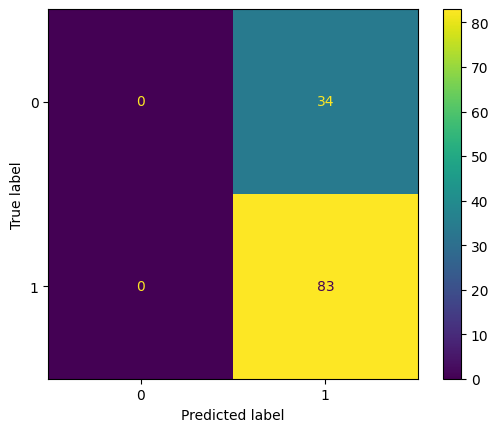

In [40]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred);

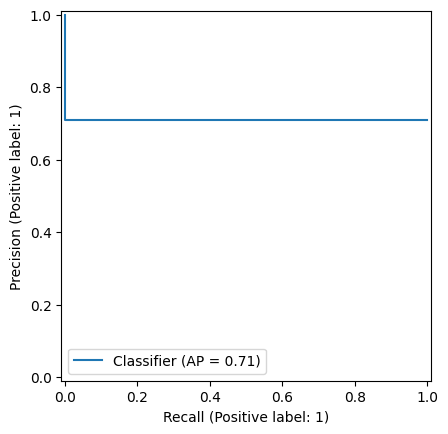

In [41]:
PrecisionRecallDisplay.from_predictions(y_test, y_pred);

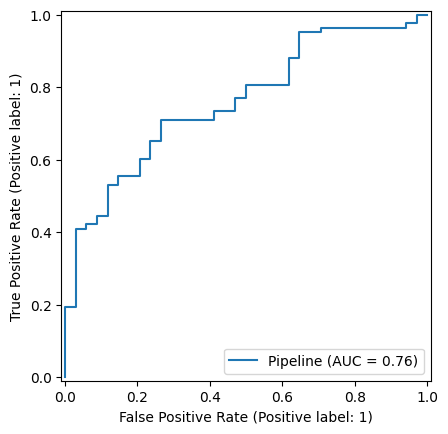

In [42]:
log_plot = RocCurveDisplay.from_estimator(logistic_model, x_test, y_test)
plt.show()

#### Random Forest

In [43]:
y_pred = tree_model.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.42      0.15      0.22        34
           1       0.72      0.92      0.81        83

    accuracy                           0.69       117
   macro avg       0.57      0.53      0.51       117
weighted avg       0.63      0.69      0.64       117



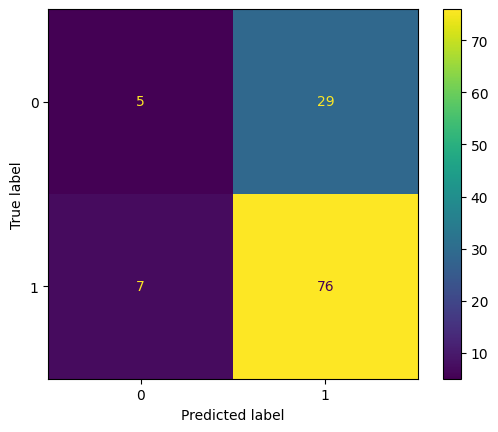

In [44]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred);

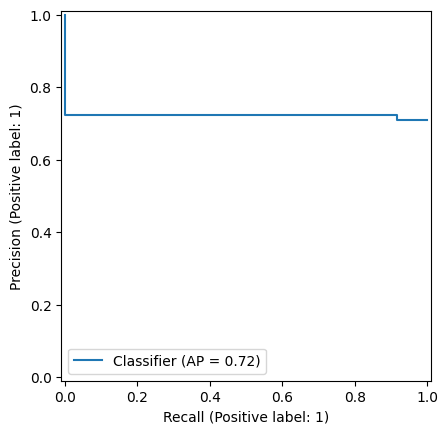

In [45]:
PrecisionRecallDisplay.from_predictions(y_test, y_pred);

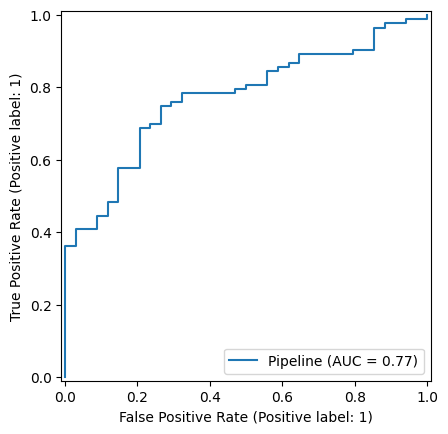

In [46]:
dt_plot = RocCurveDisplay.from_estimator(tree_model, x_test, y_test)
plt.show()

## Comparación de modelos

La regresión logística ajustada maximizó el recall hasta 1,0, pero de forma
engañosa: con el umbral por defecto predice la clase positiva para prácticamente
todos los pacientes (el reporte muestra recall 0,00 para la clase "sin
problemas"). Es la trampa clásica de optimizar solo recall cuando la clase
positiva es mayoritaria (70,8%). Eso sí: su AUC de 0,76 —calculada sobre las
probabilidades, no sobre las etiquetas predichas— muestra que el modelo sí
ordena a los pacientes; el problema está en el punto de operación, no en el
ranking.

El Random Forest ajustado (`criterion='entropy'`, `max_depth=4`,
`max_features=2`) logra recall 0,92 en la clase positiva con una capacidad
discriminativa similar (AUC ≈ 0,76) y el mejor equilibrio entre clases de los
modelos probados, por lo que se selecciona como mejor modelo de esta etapa.

Se usa la curva ROC para comparar los modelos.

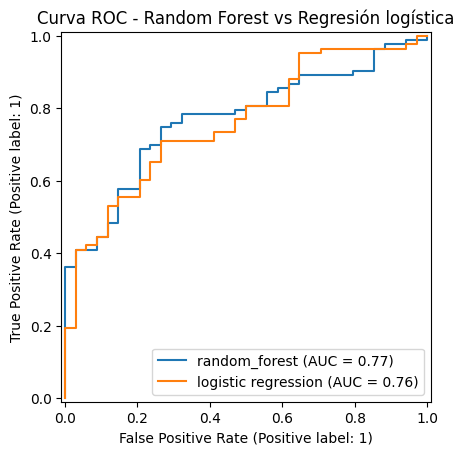

In [47]:
ax = plt.gca()
dt_plot.plot(ax=ax, name="random_forest")
log_plot.plot(ax=ax, name="logistic regression")
plt.title("Curva ROC - Random Forest vs Regresión logística")
plt.show()

## Curva de aprendizaje del Random Forest

Esta curva se usa para ver si el modelo está sobreajustando o subajustando.

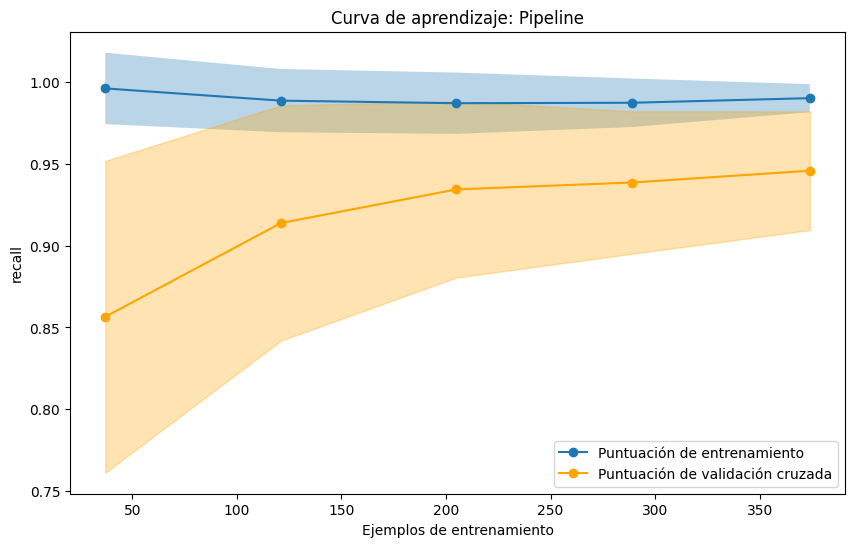

Training Sizes: [ 37 121 205 289 374]
Training Scores Mean: [0.99609091 0.98862205 0.98704941 0.9873261  0.99014418]
Training Scores Std: [0.02181837 0.01933307 0.01872709 0.01483013 0.00854634]
Test Scores Mean: [0.85651573 0.91380178 0.93438341 0.93858498 0.94579646]
Test Scores Std: [0.09530495 0.0719087  0.05388189 0.04357013 0.03629401]


In [48]:
model = tree_model

# parámetros para la curva de aprendizaje
common_params = {
    "X": x_train,
    "y": y_train,
    "train_sizes": np.linspace(0.1, 1.0, 5),
    "cv": ShuffleSplit(n_splits=50, test_size=0.2, random_state=123),
    "n_jobs": -1,
    "return_times": True,
}

scoring_metric = "recall"

# obtener los valores de la curva de aprendizaje, incluidos los tiempos
train_sizes, train_scores, test_scores, fit_times, score_times = learning_curve(
    model, **common_params, scoring=scoring_metric
)

# calcular la media y desviación estándar de las puntuaciones
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# calcular la media y desviación estándar de los tiempos de ajuste y evaluación
fit_times_mean = np.mean(fit_times, axis=1)
fit_times_std = np.std(fit_times, axis=1)
score_times_mean = np.mean(score_times, axis=1)
score_times_std = np.std(score_times, axis=1)

# graficar la curva de aprendizaje
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 6), sharey=True)
ax.plot(train_sizes, train_mean, "o-", label="Puntuación de entrenamiento")
ax.plot(train_sizes, test_mean, "o-", color="orange", label="Puntuación de validación cruzada")
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.3)
ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.3, color="orange")

# configurar el título y las etiquetas
ax.set_title(f"Curva de aprendizaje: {model.__class__.__name__}")
ax.set_xlabel("Ejemplos de entrenamiento")
ax.set_ylabel(scoring_metric)
ax.legend(loc="best")

# mostrar la gráfica
plt.show()

# imprimir los valores para el análisis
print("Training Sizes:", train_sizes)
print("Training Scores Mean:", train_mean)
print("Training Scores Std:", train_std)
print("Test Scores Mean:", test_mean)
print("Test Scores Std:", test_std)

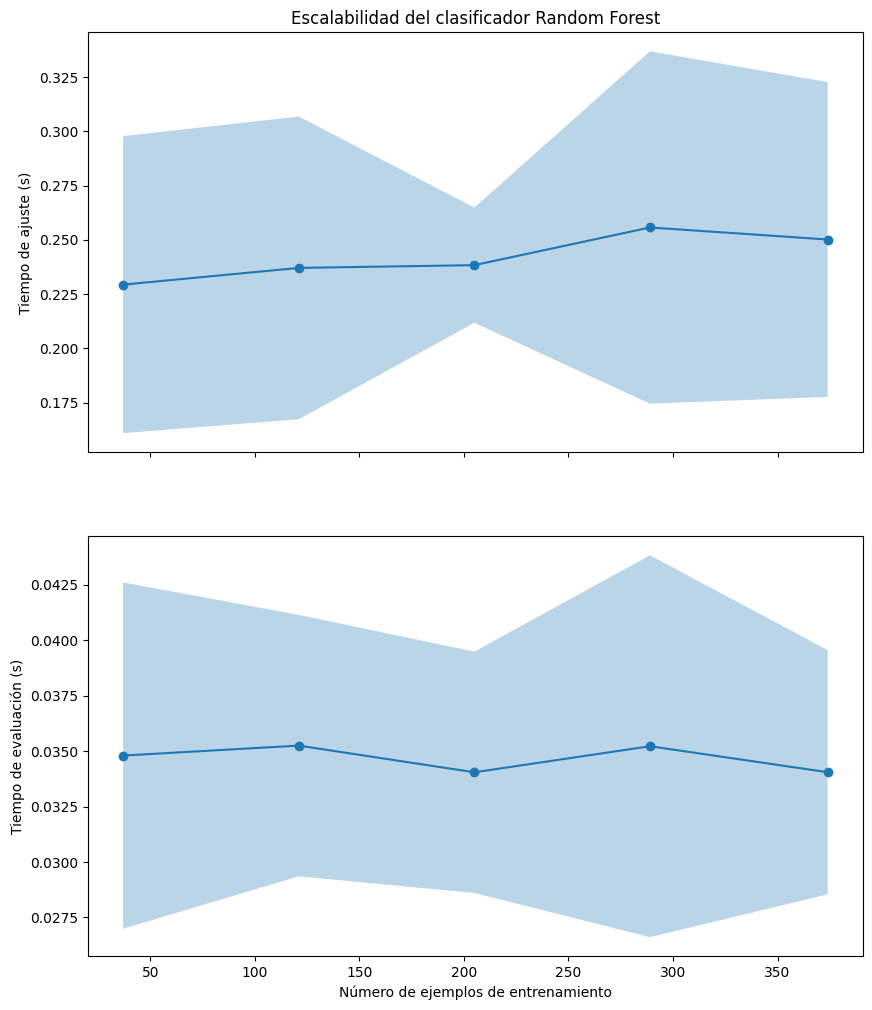

Fit Times Mean: [0.22936559 0.23707257 0.23834158 0.25571608 0.25017116]
Fit Times Std: [0.0684836  0.06980101 0.02655956 0.08123776 0.07259914]
Score Times Mean: [0.0347989  0.03524848 0.03404391 0.03522042 0.03404771]
Score Times Std: [0.00781006 0.00589782 0.00544293 0.00861192 0.00550878]


In [49]:
# graficar la escalabilidad respecto al tiempo de ajuste y evaluación
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10, 12), sharex=True)

# escalabilidad respecto al tiempo de ajuste
ax[0].plot(train_sizes, fit_times_mean, "o-")
ax[0].fill_between(
    train_sizes,
    fit_times_mean - fit_times_std,
    fit_times_mean + fit_times_std,
    alpha=0.3,
)
ax[0].set_ylabel("Tiempo de ajuste (s)")
ax[0].set_title("Escalabilidad del clasificador Random Forest")

# escalabilidad respecto al tiempo de evaluación
ax[1].plot(train_sizes, score_times_mean, "o-")
ax[1].fill_between(
    train_sizes,
    score_times_mean - score_times_std,
    score_times_mean + score_times_std,
    alpha=0.3,
)
ax[1].set_ylabel("Tiempo de evaluación (s)")
ax[1].set_xlabel("Número de ejemplos de entrenamiento")

# mostrar la gráfica
plt.show()

# imprimir los tiempos de ajuste y evaluación para el análisis
print("Fit Times Mean:", fit_times_mean)
print("Fit Times Std:", fit_times_std)
print("Score Times Mean:", score_times_mean)
print("Score Times Std:", score_times_std)

## 💾 Guardar el modelo

In [50]:
DATA_MODEL = Path.cwd().resolve().parents[1] / "models"

In [51]:
from joblib import dump

# grabar el modelo en un archivo
dump(
    Tree_pipe,
    DATA_MODEL / "pacientes_higado_clasificacion-random_forest-v1.joblib",
    protocol=5,
)

['/workspaces/Pacientes_porblemas_higado_india/models/pacientes_higado_clasificacion-random_forest-v1.joblib']

#### Probar el modelo guardado

In [52]:
from joblib import load

my_model = load(DATA_MODEL / "pacientes_higado_clasificacion-random_forest-v1.joblib")

In [53]:
# datos de prueba

x_test.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio
524,29,Male,0.8,0.2,156.0,12.0,15.0,6.8,3.7,1.1
645,52,Male,2.7,1.4,251.0,20.0,40.0,6.0,1.7,0.39
258,36,Male,0.8,0.2,182.0,31.0,34.0,6.4,3.8,1.4
507,50,Male,0.9,0.3,194.0,190.0,73.0,7.5,<NA>,1.0
203,21,Male,1.0,0.3,142.0,27.0,21.0,6.4,3.5,1.2


In [54]:
# verificar las predicciones
my_model.predict(x_test.head())

array([1, 1, 1, 1, 0])

## 📊 Análisis de los resultados

El Random Forest ajustado alcanza una accuracy del 69% en el conjunto de
prueba: recall 0,92 y F1 0,81 para la clase "problemas de hígado", pero solo
0,15 de recall para la clase "sin problemas" (macro recall 0,53).

Dos lecturas importantes:

1. **El margen sobre la referencia trivial es pequeño**: un clasificador que
   predijera siempre la clase mayoritaria acierta el 70,8%. El modelo la supera
   en capacidad discriminativa (ROC 0,53 y sobre todo la matriz de confusión
   identifica correctamente 5 de los 34 pacientes sanos), pero la separación de
   las clases con este preprocesamiento simple es limitada. Es un resultado
   conocido del dataset ILPD.
2. **El recall de la clase positiva hay que leerlo con cautela**: por el
   desbalance 71/29, valores altos (0,92) se consiguen casi "gratis". La métrica
   honesta es el promedio macro, donde el modelo obtiene 0,53 frente al 0,50
   del clasificador trivial.

Frente al baseline heurístico del notebook 01, que usa umbrales clínicos sobre
cuatro pruebas, el Random Forest gana principalmente al integrar las 10
variables del panel completo; el notebook 06 (AutoML) muestra que añadir el
preprocesamiento rico del Feature Engineering (transformación logarítmica y
cocientes clínicos) mejora aún más el desempeño.

## 🧑‍🔬 Recomendaciones

1. **Continuar con el modelo actual**: dado que el Random Forest
   ajustado generaliza de forma estable (la curva de aprendizaje muestra
   validación convergiendo a ~0,95 de recall con el tamaño de entrenamiento
   disponible), es viable continuar con esta configuración como modelo de
   referencia de la etapa; el notebook 06 la compara con alternativas AutoML
   
2. **Modelos más complejos**: probar modelos como XGBoost o LightGBM para ver si
   mejoran el desempeño; el notebook
   `06-automl_model_selection-mba-2026-08-20.ipynb` ya explora esta vía con
   AutoML (FLAML).

3. **Validación del proceso**: validar el pipeline completo con chequeos de
   integridad y de distribuciones (`05-model_validation-mba-2026-08-19.ipynb`) y registrar los
   experimentos con MLflow (`04-experiment-track-model-mba-2026-08-19.ipynb`).

## 📖 Referencias

- <https://joserzapata.github.io/courses/python-ciencia-datos/ml/>
- <https://joserzapata.github.io/courses/python-ciencia-datos/clasificacion/>
- Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow: Concepts, Tools, and Techniques to Build Intelligent Systems 2nd Edition - Aurélien Géron
- Dataset ILPD (Indian Liver Patient Dataset):
  <https://archive.ics.uci.edu/dataset/225/ilpd+indian+liver+patient+dataset>